# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 03: Análise Exploratória de Dados (EDA)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora  |
|-------------------------------|---------------|-------|
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font> |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font> |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font> |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratório` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_02_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: data de criação, domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.
- #### <font color='cyan'>S., B. & Nagapadma, R. (2023). RT-IoT2022. UCI Machine Learning Repository. https://doi.org/10.24432/C5P338.</font>

O dataset RT-IoT2022 foi criado em 4 de janeiro de 2024, pertence ao domínio de redes e segurança IoT e tem como objetivo apoiar pesquisas voltadas ao desenvolvimento de sistemas de detecção de intrusões. Ele reúne informações de tráfego de rede em cenários reais e simulados, abrangendo tanto comportamentos normais de dispositivos IoT, quanto padrões adversariais de ataques.

## <font color='green'>Preparação</font>

In [3]:
!pip install pandas ucimlrepo

In [4]:
import pandas as pd

from pprint import pprint
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=942)

In [5]:
pprint(ds.metadata)

{'abstract': 'The RT-IoT2022, a proprietary dataset derived from a real-time '
             'IoT infrastructure, is introduced as a comprehensive resource '
             'integrating a diverse range of IoT devices and sophisticated '
             'network attack methodologies. This dataset encompasses both '
             'normal and adversarial network behaviours, providing a general '
             'representation of real-world scenarios.\n'
             'Incorporating data from IoT devices such as ThingSpeak-LED, '
             'Wipro-Bulb, and MQTT-Temp, as well as simulated attack scenarios '
             'involving Brute-Force SSH attacks, DDoS attacks using Hping and '
             'Slowloris, and Nmap patterns, RT-IoT2022 offers a detailed '
             'perspective on the complex nature of network traffic. The '
             'bidirectional attributes of network traffic are meticulously '
             'captured using the Zeek network monitoring tool and the '
             'Flowm

In [6]:
ds.variables

,name,role,type,demographic,description,units,missing_values
0,id.orig_p,Feature,Integer,None,None,None,no
1,id.resp_p,Feature,Integer,None,None,None,no
2,proto,Feature,Categorical,None,None,None,no
3,service,Feature,Continuous,None,None,None,no
4,flow_duration,Feature,Continuous,None,None,None,no
...,...,...,...,...,...,...,...
80,fwd_init_window_size,Feature,Integer,None,None,None,no
81,bwd_init_window_size,Feature,Integer,None,None,None,no
82,fwd_last_window_size,Feature,Integer,None,None,None,no
83,Attack_type,Target,Categorical,None,None,None,no


In [7]:
X = ds.data.features
y = ds.data.targets

df = pd.concat([X, y], axis='columns')

df

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,59247,63331,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123113,59247,64623,tcp,-,0.000007,1,1,0,0,144631.172400,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123114,59247,64680,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123115,59247,65000,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN


In [8]:
df.dtypes

,0
id.orig_p,int64
id.resp_p,int64
proto,object
service,object
flow_duration,float64
...,...
idle.std,float64
fwd_init_window_size,int64
bwd_init_window_size,int64
fwd_last_window_size,int64


## <font color='green'>**2.1 Conjuntos de Dados**</font>

### <font color='cyan'>Q1: Exiba 10 amostras aleatórias do conjunto de dados.</font>

In [9]:
df.sample(10)

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
43497,25549,21,tcp,-,0.000001,1,1,1,0,1.048576e+06,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
61713,43837,21,tcp,-,0.000004,1,1,1,0,2.467238e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
103684,490,21,tcp,-,0.000001,1,1,1,0,1.048576e+06,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
101813,54612,21,tcp,-,0.000001,1,1,1,0,8.388608e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
54325,36448,21,tcp,-,0.000006,1,1,1,0,1.677722e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
37848,19900,21,tcp,-,0.000004,1,1,1,0,2.467238e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
107005,1572,21,tcp,-,0.000001,1,1,1,0,1.048576e+06,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
7896,58092,443,tcp,ssl,1.277420,15,11,3,8,1.174242e+01,...,0.0,0.0,0.0,0.0,0.0,0.0,64240,26847,0,Thing_Speak
87826,21787,21,tcp,-,0.000004,1,1,1,0,2.467238e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
93429,14134,21,tcp,-,0.000001,1,1,1,0,1.048576e+06,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping


### <font color='cyan'>Q2: Quantas amostras o conjunto de dados possui?</font>

In [10]:
print(len(df))

123117


### <font color='cyan'>Q3: Quantas características o conjunto de dados possui?</font>

In [11]:
print(len(df.columns))

84


### <font color='cyan'>Q4: O conjunto de dados possui características numéricas? Se sim, escreva seu(s) nome(s) e classifique-a(s) como contínua(s) e/ou discreta(s).</font>
- #### <font color='cyan'>Observação: considere que uma caraterística numérica é discreta se possui menos que 50 valores únicos.</font>

In [12]:
num_col = df.select_dtypes(include=['int64','float64'])

print({col: "Discreta" if df[col].nunique() < 50 else "Contínua" for col in num_col.columns})


{'id.orig_p': 'Contínua', 'id.resp_p': 'Contínua', 'flow_duration': 'Contínua', 'fwd_pkts_tot': 'Contínua', 'bwd_pkts_tot': 'Contínua', 'fwd_data_pkts_tot': 'Contínua', 'bwd_data_pkts_tot': 'Contínua', 'fwd_pkts_per_sec': 'Contínua', 'bwd_pkts_per_sec': 'Contínua', 'flow_pkts_per_sec': 'Contínua', 'down_up_ratio': 'Contínua', 'fwd_header_size_tot': 'Contínua', 'fwd_header_size_min': 'Discreta', 'fwd_header_size_max': 'Discreta', 'bwd_header_size_tot': 'Contínua', 'bwd_header_size_min': 'Discreta', 'bwd_header_size_max': 'Discreta', 'flow_FIN_flag_count': 'Discreta', 'flow_SYN_flag_count': 'Discreta', 'flow_RST_flag_count': 'Discreta', 'fwd_PSH_flag_count': 'Contínua', 'bwd_PSH_flag_count': 'Contínua', 'flow_ACK_flag_count': 'Contínua', 'fwd_URG_flag_count': 'Discreta', 'bwd_URG_flag_count': 'Discreta', 'flow_CWR_flag_count': 'Discreta', 'flow_ECE_flag_count': 'Discreta', 'fwd_pkts_payload.min': 'Contínua', 'fwd_pkts_payload.max': 'Contínua', 'fwd_pkts_payload.tot': 'Contínua', 'fwd_pkt

### <font color='cyan'>Q5: O conjunto de dados possui características categóricas? Se sim, escreva seu(s) nome(s) e sua(s) quantidade(s) de valores únicos.</font>

In [13]:
cat_col = df.select_dtypes(include=['object'])

for col in cat_col.columns:
    print(f"{col}: {df[col].nunique()}")


proto: 3
service: 10
Attack_type: 12


## <font color='green'>**2.2 Estatística Descritiva Básica**</font>

### <font color='cyan'> Q6: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

flow_duration

### <font color='cyan'> Q7: Calcule e mostre suas Medidas de Tendência Central (média, mediana e moda).</font>

In [14]:
media = df['flow_duration'].mean()
print(f"Média: {media}")

mediana = df['flow_duration'].median()
print(f"Mediana: {mediana}")

moda = df['flow_duration'].mode()
print(f"Moda: {moda}")

Média: 3.8095657700073917
Mediana: 4e-06
Moda: 0    0.000004
Name: flow_duration, dtype: float64


### <font color='cyan'> Q8: Calcule e mostre suas Medidas de Dispersão (mínimo, máximo e amplitude).</font>

In [15]:
min = df['flow_duration'].min()
print(f"Mínimo: {min}")

max = df['flow_duration'].max()
print(f"Máximo: {max}")

amplitude = max - min
print(f"Amplitude: {amplitude}")

Mínimo: 0.0
Máximo: 21728.33558
Amplitude: 21728.33558


## <font color='green'>**2.3 Análise Univariada**</font>

### <font color='cyan'> Q9: Escolha uma característica categórica do conjunto de dados. Escreva seu nome a seguir.</font>

Attack_type

### <font color='cyan'> Q10: Crie e exiba uma Tabela de Frequência e/ou um Gráfico de Barras para a característica escolhida.</font>

Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


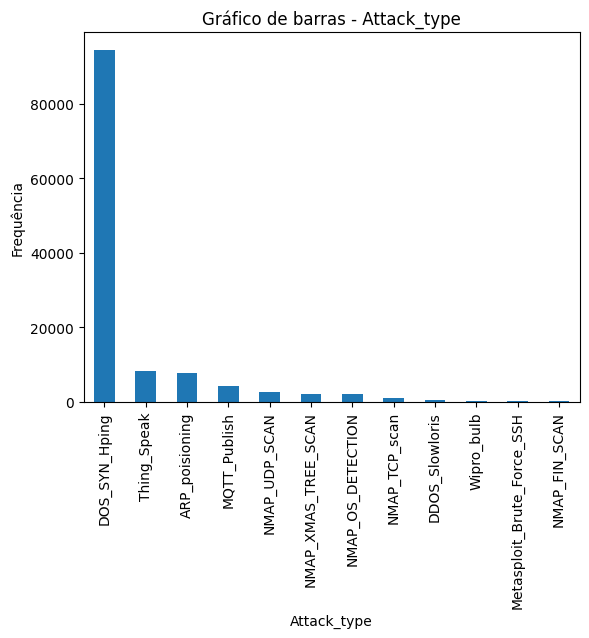

In [16]:
# Tabela de frequências
tab_freq = df['Attack_type'].value_counts()
print(tab_freq)

import matplotlib.pyplot as plt

# Gráfico de barras
tab_freq.plot(kind='bar')
plt.xlabel('Attack_type')
plt.ylabel('Frequência')
plt.title('Gráfico de barras - Attack_type')
plt.show()

### <font color='cyan'> Q11: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

flow_duration

### <font color='cyan'> Q13: Crie e exiba um Histograma e/ou uma Estimativa de Densidade por Kernel (KDE) para a característica escolhida.</font>

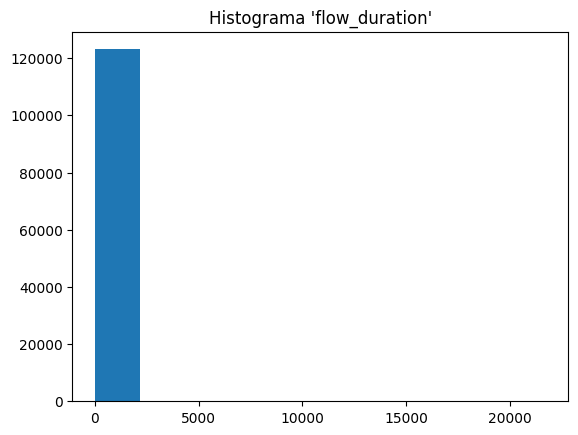

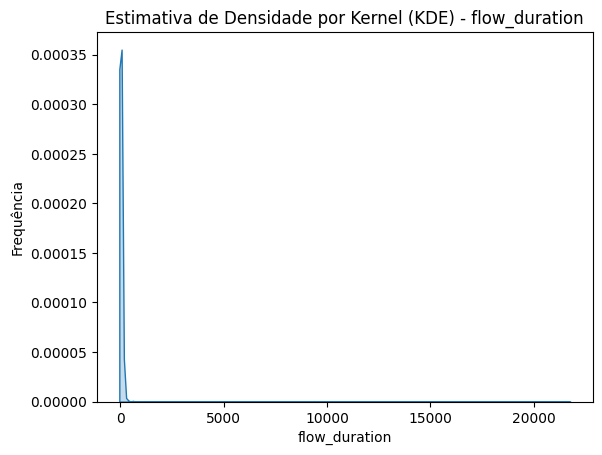

In [17]:
# Histograma
plt.hist(df['flow_duration'], bins=10)
plt.title("Histograma 'flow_duration'")
plt.show()

# KDE
import seaborn as sns
sns.kdeplot(df['flow_duration'], fill=True)
plt.title("Estimativa de Densidade por Kernel (KDE) - flow_duration")
plt.xlabel("flow_duration")
plt.ylabel("Frequência")
plt.show()


## <font color='green'>**2.4 Análise Bivariada**</font>

### <font color='cyan'> Q14: Escolha duas características do conjuntos de dados. Escreva seus nome a seguir.</font>

flow_duration e Attack_type

### <font color='cyan'>Q15: De acordo com os tipos das características escolhidas, produza pelo menos uma visualização de análise bivariada. Exemplos:</font>
- ### <font color='cyan'>Numérica vs Numérica: Scatter Plot ou Hexbin Plot;</font>
- ### <font color='cyan'>Categórica vs Numérica: Box Plot ou Violin Plot;</font>
- ### <font color='cyan'>Categórica vs Categórica: Crosstab, Grouped Bar Chart ou Stacked Bar Chart.</font>

/tmp/ipykernel_324/2674065290.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Attack_type", y="flow_duration", data=df, palette="Set2")


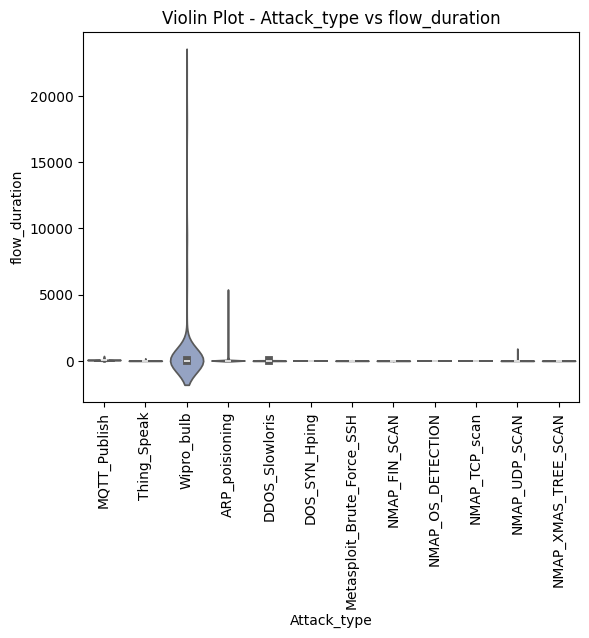

In [18]:
sns.violinplot(x="Attack_type", y="flow_duration", data=df, palette="Set2")
plt.xticks(rotation=90)
plt.title("Violin Plot - Attack_type vs flow_duration")
plt.show()


## <font color='green'>**2.5 Identificação de Problemas nos Dados**</font>

### <font color='cyan'> Q16: Inspecione o conjuntos de dados para verificar se há:</font>
- #### <font color='cyan'> Dados Ausentes;</font>
- #### <font color='cyan'> Valores Atípicos (Outliers);</font>
- #### <font color='cyan'> Valores Duplicados;</font>
### <font color='cyan'> Reporte sua(s) descoberta(s) a seguir.</font>

In [19]:
# ausentes
print(df.isnull().sum())

id.orig_p               0
id.resp_p               0
proto                   0
service                 0
flow_duration           0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 84, dtype: int64


Não há dados ausentes.

In [20]:
# duplicados
print(df.duplicated().sum())

5195


Há 5195 dados duplicados.

        id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0           38667       1883   tcp    mqtt      32.011598             9   
1           51143       1883   tcp    mqtt      31.883584             9   
2           44761       1883   tcp    mqtt      32.124053             9   
3           60893       1883   tcp    mqtt      31.961063             9   
4           51087       1883   tcp    mqtt      31.902362             9   
...           ...        ...   ...     ...            ...           ...   
123112      59247      63331   tcp       -       0.000006             1   
123113      59247      64623   tcp       -       0.000007             1   
123114      59247      64680   tcp       -       0.000006             1   
123115      59247      65000   tcp       -       0.000006             1   
123116      59247      65129   tcp       -       0.000006             1   

        bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  \
0                  

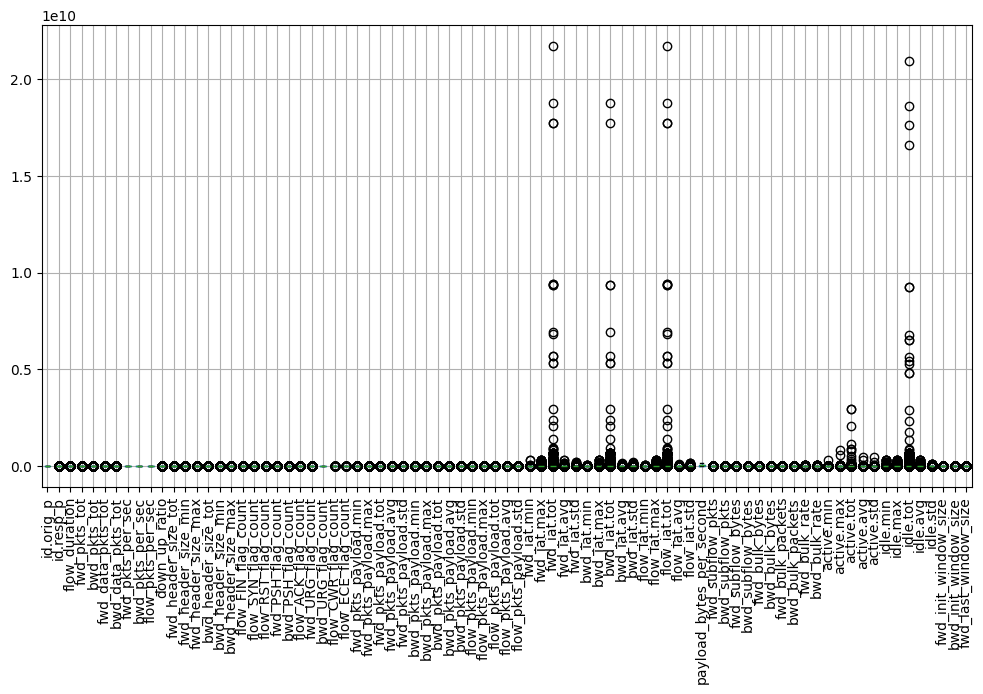

In [21]:
# outliers
import numpy as np
from scipy import stats

num_cols = df.select_dtypes(include='number').columns
z_scores = np.abs(stats.zscore(df[num_cols]))
outliers_por_linha = (z_scores > 3).any(axis=1)
df_outliers = df[outliers_por_linha]
print(df_outliers)

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))
print(outliers.sum())


df[num_cols].boxplot(figsize=(12,6))
plt.xticks(rotation=90)
plt.show()



Algumas colunas apresentam valores extremos, detectados pelo método de Z-score/IQR. Esses valores podem ser legítimos ou ruído, e precisam de análise contextual.

### <font color='cyan'> Q17: Caso problemas tenham sido encontrados, proponha soluções para eles.</font>
### <font color='cyan'> Exiba o conjunto de dados antes e depois de aplicar as soluções, enfatizando as mudanças.</font>

In [22]:
# df antes das mudanças
df

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,59247,63331,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123113,59247,64623,tcp,-,0.000007,1,1,0,0,144631.172400,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123114,59247,64680,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123115,59247,65000,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN


In [23]:
# não há dados ausentes a corrigir

In [24]:
# dados duplicados
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [31]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    mediana = df[col].median()
    df.loc[outliers[col], col] = mediana

df

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667.0,21.0,tcp,mqtt,0.000004,1.0,1.0,1.0,0.0,0.281148,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,MQTT_Publish
1,51143.0,21.0,tcp,mqtt,0.000004,1.0,1.0,1.0,0.0,0.282277,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,MQTT_Publish
2,44761.0,21.0,tcp,mqtt,0.000004,1.0,1.0,1.0,0.0,0.280164,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,MQTT_Publish
3,60893.0,21.0,tcp,mqtt,0.000004,1.0,1.0,1.0,0.0,0.281593,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,MQTT_Publish
4,51087.0,21.0,tcp,mqtt,0.000004,1.0,1.0,1.0,0.0,0.282111,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,MQTT_Publish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,59247.0,21.0,tcp,-,0.000006,1.0,1.0,1.0,0.0,167772.160000,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,NMAP_XMAS_TREE_SCAN
123113,59247.0,21.0,tcp,-,0.000007,1.0,1.0,1.0,0.0,144631.172400,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,NMAP_XMAS_TREE_SCAN
123114,59247.0,21.0,tcp,-,0.000006,1.0,1.0,1.0,0.0,167772.160000,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,NMAP_XMAS_TREE_SCAN
123115,59247.0,21.0,tcp,-,0.000006,1.0,1.0,1.0,0.0,167772.160000,...,0.0,0.0,0.0,0.0,0.0,0.0,64.0,0.0,64.0,NMAP_XMAS_TREE_SCAN


## <font color='green'>**2.6 Correlação Simples**</font>

### <font color='cyan'> Q18: Escolha duas características numéricas do conjuntos de dados. Escreva seus nomes a seguir.</font>

fwd_data_pkts_tot e fwd_pkts_per_sec



### <font color='cyan'> Q19: Calcule e exiba o Coeficiente de Correlação de Pearson ($r$) entre elas.</font>

Correlação de Pearson:
                   fwd_pkts_tot  fwd_data_pkts_tot
fwd_pkts_tot           1.000000           0.817243
fwd_data_pkts_tot      0.817243           1.000000


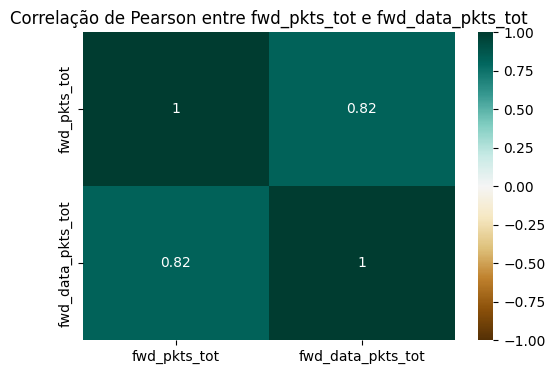

In [26]:
corr = df[['fwd_pkts_tot', 'fwd_data_pkts_tot']].corr(method='pearson')

print("Correlação de Pearson:")
print(corr)

plt.figure(figsize=(6,4))
sns.heatmap(corr, cmap="BrBG", annot=True, vmin=-1, vmax=1)
plt.title("Correlação de Pearson entre fwd_pkts_tot e fwd_data_pkts_tot")
plt.show()


### <font color='cyan'> Q20: Interprete o coeficiente de correlação, em termos de sinal e magnitude.</font>

O coeficiente de correlação de Pearson entre fwd_pkts_tot e fwd_data_pkts_tot é muito próxima de 1. Essa análise confirma que essas duas variáveis carregam informações fortemente relacionadas, o que pode indicar redundância nos dados.  Pode ser interessante avaliar se ambas são necessárias ou se uma já representa bem a outra.